# Exam Score Predictor

## Problem Statement

The objective of this project is to predict a student's exam score based on demographic, academic, and lifestyle factors such as study hours, attendance, sleep hours, study methods, and internet access.

This is a supervised machine learning regression problem where the target variable is the exam score.

## Loading Dataset 
In this step, the dataset is loaded into a pandas DataFrame for further analysis and preprocessing.

In [3]:
# imported pandas to do see the data and do some preprocessing
import pandas as pd

In [5]:
# imported the csv file in the jupyter lab
df = pd.read_csv("D:/Downloads/Exam_Score_Prediction.csv")

## Initial Data Inspection 

In [8]:
df.head() # to see the data 

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [12]:
df.isnull().sum()

student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [14]:
df.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


In [16]:
df.duplicated().sum()

0

<b>Key Finidings: </b>
- The dataset contains no missing values.
- No immediate data quality issues were identified.
- All variables have appropriate data types.
- The dataset is ready for exploratory data analysis and preprocessing.

## Exploratory Data Analysis

<b>Deleting `student_id`</b> column because it will not impact the Exam Score

In [21]:
df = df.drop("student_id", axis=1)

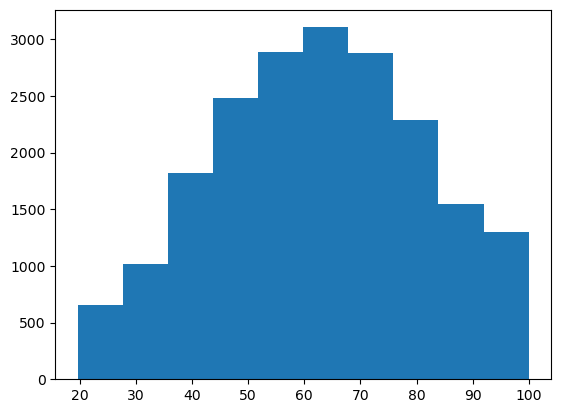

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.hist(df["exam_score"])
plt.show()

#### Observation

The exam scores appear to follow an approximately normal distribution with a slight concentration around the middle score range.

No severe skewness is observed.

### Understanding the correlation between numerical columns and Score

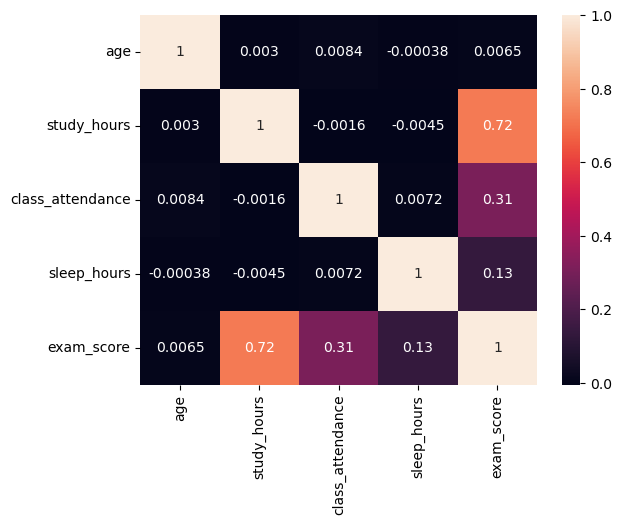

In [26]:
numeric_cols = df.select_dtypes(include=["int64","float64"])

sns.heatmap(numeric_cols.corr(),annot=True)
plt.show()

#### Correlation Analysis

A correlation matrix was used to examine the relationship between numerical features and the target variable (exam_score).

##### Key Findings

- Study hours show the strongest positive correlation with exam score (0.72).
- Class attendance has a moderate positive correlation with exam score (0.31).
- Sleep hours have a weak positive correlation with exam score (0.13).
- Age shows almost no linear relationship with exam score (0.0065).

##### Feature Selection Decision

Since age exhibits a negligible correlation with the target variable, it is unlikely to contribute significantly to score prediction. Therefore, the age feature is removed from the dataset for further experimentation.

In [30]:
df = df.drop("age", axis=1)

### Understanding the relation between Categorical columns and Score

In [33]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print("\n",df[col].value_counts())


 gender
other     6726
male      6695
female    6579
Name: count, dtype: int64

 course
bca        2902
ba         2896
b.sc       2878
b.com      2864
bba        2836
diploma    2826
b.tech     2798
Name: count, dtype: int64

 internet_access
yes    16988
no      3012
Name: count, dtype: int64

 sleep_quality
average    6694
poor       6687
good       6619
Name: count, dtype: int64

 study_method
self-study       4079
online videos    4069
coaching         4036
group study      3922
mixed            3894
Name: count, dtype: int64

 facility_rating
medium    6760
low       6638
high      6602
Name: count, dtype: int64

 exam_difficulty
moderate    9878
easy        6141
hard        3981
Name: count, dtype: int64


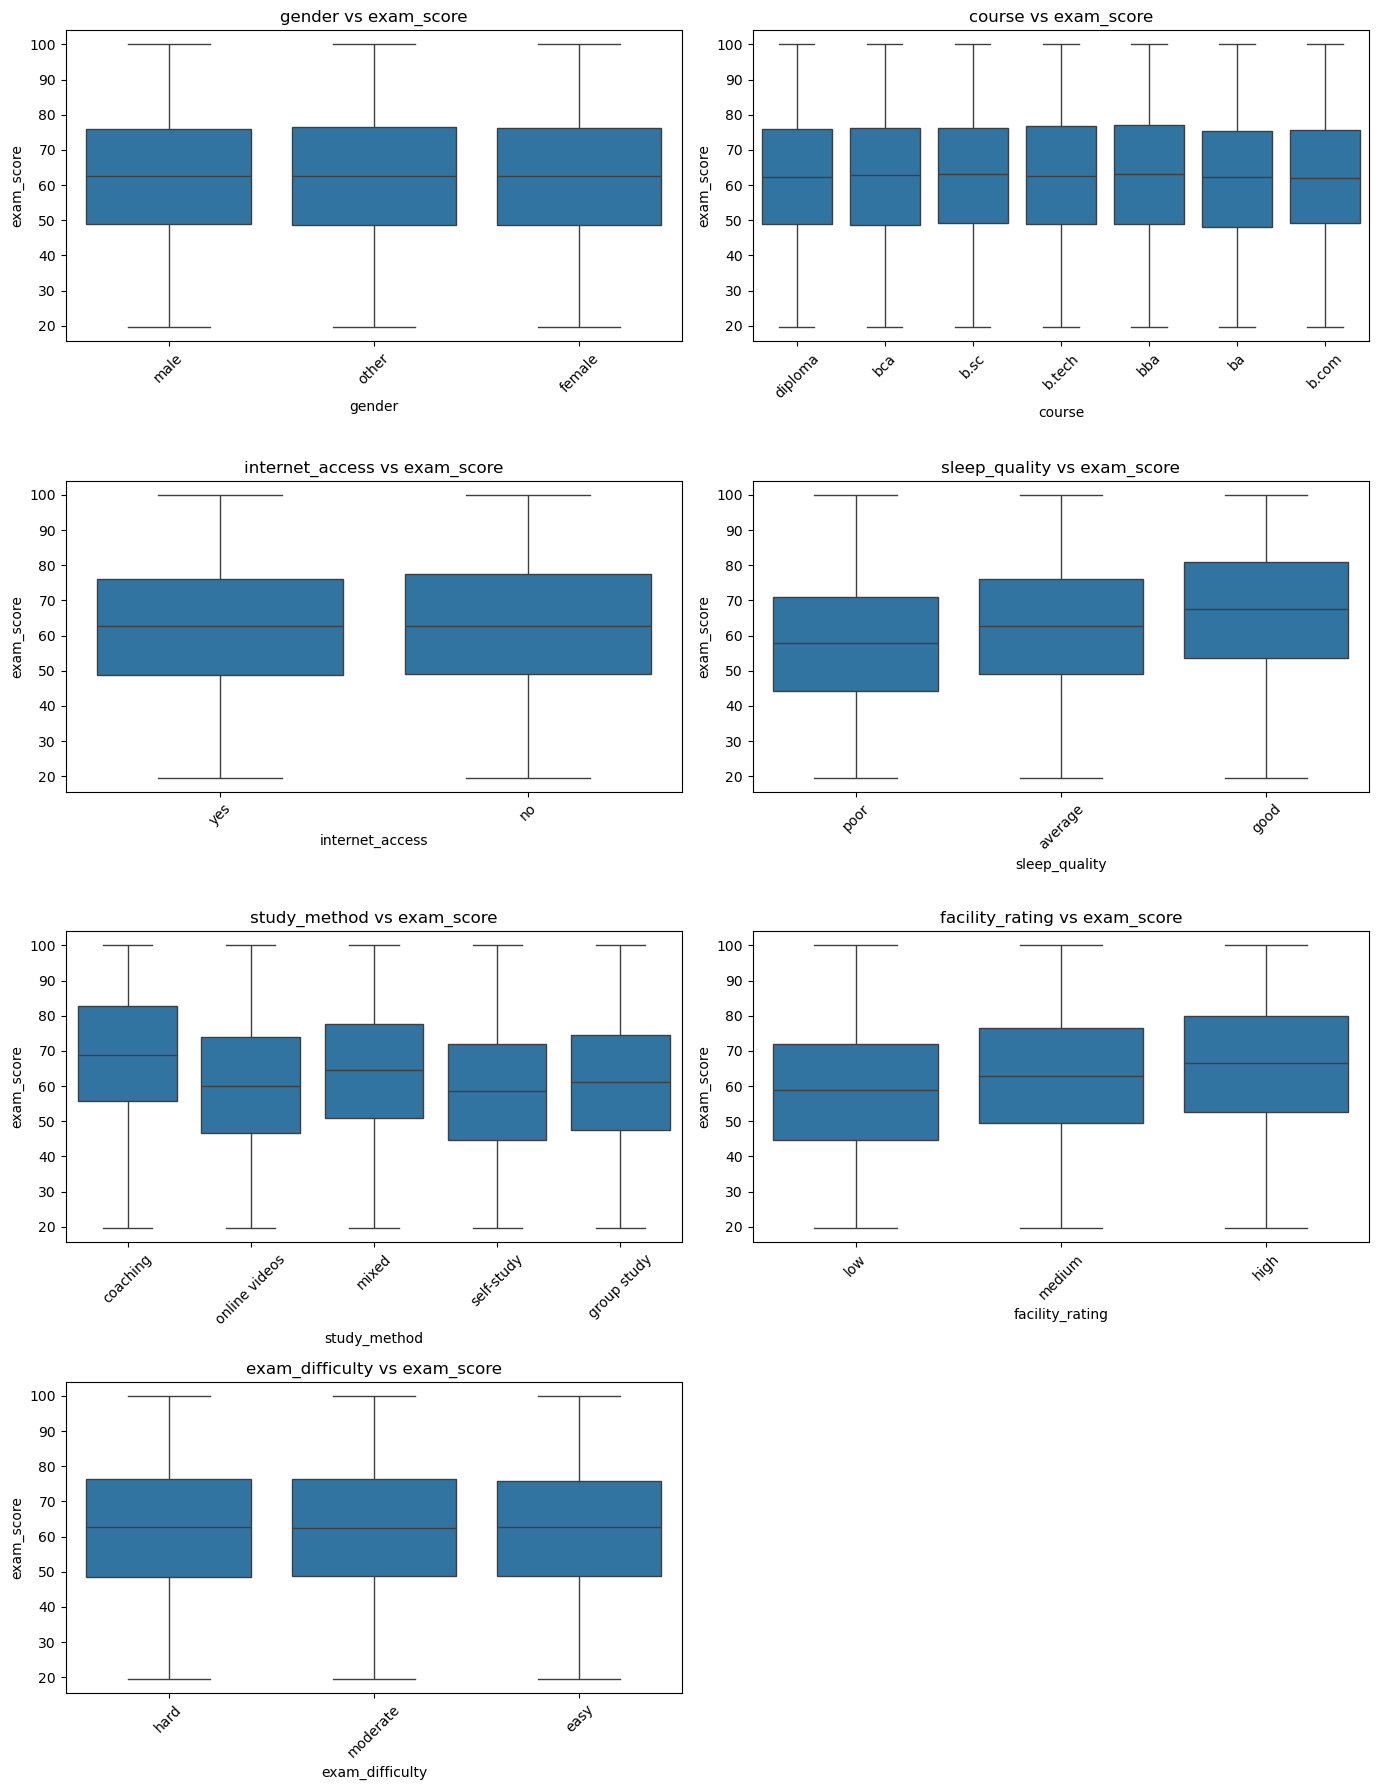

In [35]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(x=col, y='exam_score', data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs exam_score", fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('exam_score', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.delaxes(axes[7])

#### Key Findings

- The categorical variables are reasonably balanced, with no severe class imbalance observed.

# Data Splitting (Train-Test Split)

In [39]:
X = df.drop("exam_score", axis=1)
X

,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard
1,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate
2,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate
3,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate
4,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate
...,...,...,...,...,...,...,...,...,...,...
19995,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy
19996,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate
19997,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy
19998,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate


In [41]:
y = df["exam_score"]
y

0        58.9
1        54.8
2        90.3
3        29.7
4        43.7
         ... 
19995    86.5
19996    60.9
19997    64.5
19998    79.0
19999    71.0
Name: exam_score, Length: 20000, dtype: float64

In [43]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# i am using 80% of the data for trainig and 20% of the data for testing 

# Feature Transformation

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),                 
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Training Multiple Models

I will Train multiple models then i will choose the best one to predict the student score to ensure better accuracy.

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

### Linear Regression

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("model",LinearRegression())
])

lr_pipeline.fit(X_train,y_train)
y_pred = lr_pipeline.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

MAE: 7.863048856855448
RMSE: 9.772586165747105


### Random Forest

In [56]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

# Pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

# Hyperparameter Grid
rf_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 12, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [2, 4]
}

# Grid Search
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Training
rf_grid.fit(X_train, y_train)

# Best Model
best_rf = rf_grid.best_estimator_

# Prediction
y_pred = best_rf.predict(X_test)

# Results
print("Best Parameters:", rf_grid.best_params_)
print("Best CV Score:", rf_grid.best_score_)
print("Test R2 Score:", r2_score(y_test, y_pred))
print("Test MAE:", mean_absolute_error(y_test, y_pred))

Best Parameters: {'model__max_depth': 12, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Best CV Score: 0.7101390818251667
Test R2 Score: 0.7094904339349581
Test MAE: 8.222204730643282


### Decision Tree

In [58]:
from sklearn.tree import DecisionTreeRegressor

# Pipeline
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

# Hyperparameter Grid
dt_params = {
    "model__max_depth": [3, 5, 10, 15, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__criterion": ["squared_error", "friedman_mse"]
}

# Grid Search
dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Training
dt_grid.fit(X_train, y_train)

# Best Model
best_dt = dt_grid.best_estimator_

# Prediction
y_pred = best_dt.predict(X_test)

# Evaluation
print("Best Parameters:", dt_grid.best_params_)
print("Best CV Score:", dt_grid.best_score_)
print("Test R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)


Best Parameters: {'model__criterion': 'squared_error', 'model__max_depth': 10, 'model__min_samples_leaf': 8, 'model__min_samples_split': 20}
Best CV Score: 0.6435005708045045
Test R2 Score: 0.6520714789412387
MAE: 8.939614742108484
RMSE: 11.155850231943315


### Gradient Boosting 

In [60]:
from sklearn.ensemble import GradientBoostingRegressor

# Pipeline
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

# Hyperparameter Grid
gb_params = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_samples_split": [2, 5, 10],
    "model__subsample": [0.8, 1.0]
}

# Grid Search
gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Training
gb_grid.fit(X_train, y_train)

# Best Model
best_gb = gb_grid.best_estimator_

# Prediction
y_pred = best_gb.predict(X_test)

# Evaluation
print("Best Parameters:", gb_grid.best_params_)
print("Best CV Score:", gb_grid.best_score_)
print("Test R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_split': 10, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV Score: 0.7271315126255771
Test R2 Score: 0.7296715215212932
MAE: 7.935331255772614
RMSE: 9.83339669615187


### XG Boost

In [62]:
pip install xgboost

In [63]:
from xgboost import XGBRegressor

# Pipeline
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ))
])

# Hyperparameter Grid
xgb_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

# Grid Search
xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Training
xgb_grid.fit(X_train, y_train)

# Best Model
best_xgb = xgb_grid.best_estimator_

# Prediction
y_pred = best_xgb.predict(X_test)

# Evaluation
print("Best Parameters:", xgb_grid.best_params_)
print("Best CV Score:", xgb_grid.best_score_)
print("Test R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

Best Parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV Score: 0.7272407044482175
Test R2 Score: 0.7293511766845021
MAE: 7.932822076313019
RMSE: 9.839221360284819


# Choosing the Best Model

In [65]:
models = {
    "Linear Regression": lr_pipeline,
    "Decision Tree": dt_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

cv_scores = {
    "Linear Regression": "N/A",
    "Decision Tree": dt_grid.best_score_,
    "Random Forest": rf_grid.best_score_,
    "Gradient Boosting": gb_grid.best_score_,
    "XGBoost": xgb_grid.best_score_
}

results = []

for name, model in models.items():

    # Train Score
    train_r2 = model.score(X_train, y_train)

    # Test Score
    test_r2 = model.score(X_test, y_test)

    # Predictions
    y_pred = model.predict(X_test)

    # Errors
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5

    # Gap (Overfitting Check)
    gap = train_r2 - test_r2

    results.append([
        name,
        round(train_r2, 4),
        round(cv_scores[name], 4) if cv_scores[name] != "N/A" else "N/A",
        round(test_r2, 4),
        round(mae, 4),
        round(rmse, 4),
        round(gap, 4)
    ])

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train R²",
        "CV R²",
        "Test R²",
        "MAE",
        "RMSE",
        "Gap"
    ]
)

comparison_df = comparison_df.sort_values(
    by="Test R²",
    ascending=False
)

comparison_df

,Model,Train R²,CV R²,Test R²,MAE,RMSE,Gap
0,Linear Regression,0.7320,N/A,0.7330,7.8630,9.7726,-0.0010
3,Gradient Boosting,0.7425,0.7271,0.7297,7.9353,9.8334,0.0129
4,XGBoost,0.7414,0.7272,0.7294,7.9328,9.8392,0.0120
2,Random Forest,0.8454,0.7101,0.7095,8.2222,10.1938,0.1359
1,Decision Tree,0.7593,0.6435,0.6521,8.9396,11.1559,0.1072


#### Result
The Linear Regression model achieved an R² score of `0.7330` without overfitting and demonstrated strong predictive performance.

In [67]:
best_model = lr_pipeline

# Saving the Final Model

After evaluating multiple machine learning models, I selected the best-performing model and saved it for deployment.

I will use this same trained model in my Flask web application to predict students' exam scores based on the inputs provided by users through the web form.

In [69]:
import joblib
joblib.dump(best_model, "Student_exam_score_predictor.pkl")

['Student_exam_score_predictor.pkl']

# Connect With Me

- **GitHub Link:** [Rajnish Tiwari](https://github.com/Rajnish-28)
  
- **LinkedIn Link:** [Rajnish Tiwari](https://in.linkedin.com/in/rajnishtiwari28?trk=profile-badge")
- **Email:** rajnish592006@gmail.com